# VortexTech Week 3 — Regression & Clustering
## Dataset: Hospital Length of Stay (Microsoft, via Kaggle)
Link: [Dataset](https://www.kaggle.com/datasets/aayushchou/hospital-length-of-stay-dataset-microsoft)

**Target (regression):** `lengthofstay` — number of days patient admitted.

**Clustering:** grouping patients by health indicators (hematocrit, bmi, pulse).


In [1]:
import pandas as pd

df = pd.read_csv("LengthOfStay.csv")
df.head()

,eid,vdate,rcount,gender,dialysisrenalendstage,asthma,irondef,pneum,substancedependence,psychologicaldisordermajor,...,glucose,bloodureanitro,creatinine,bmi,pulse,respiration,secondarydiagnosisnonicd9,discharged,facid,lengthofstay
0,1,8/29/2012,0,F,0,0,0,0,0,0,...,192.476918,12.0,1.390722,30.432418,96,6.5,4,9/1/2012,B,3
1,2,5/26/2012,5+,F,0,0,0,0,0,0,...,94.078507,8.0,0.943164,28.460516,61,6.5,1,6/2/2012,A,7
2,3,9/22/2012,1,F,0,0,0,0,0,0,...,130.530524,12.0,1.065750,28.843812,64,6.5,2,9/25/2012,B,3
3,4,8/9/2012,0,F,0,0,0,0,0,0,...,163.377028,12.0,0.906862,27.959007,76,6.5,1,8/10/2012,A,1
4,5,12/20/2012,0,F,0,0,0,1,0,1,...,94.886654,11.5,1.242854,30.258927,67,5.6,2,12/24/2012,E,4


## Step 1: Data Cleaning
Dropping ID/date columns not useful for prediction, removing missing rows,
and one-hot encoding categorical columns.

In [2]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   eid                         100000 non-null  int64  
 1   vdate                       100000 non-null  str    
 2   rcount                      100000 non-null  str    
 3   gender                      100000 non-null  str    
 4   dialysisrenalendstage       100000 non-null  int64  
 5   asthma                      100000 non-null  int64  
 6   irondef                     100000 non-null  int64  
 7   pneum                       100000 non-null  int64  
 8   substancedependence         100000 non-null  int64  
 9   psychologicaldisordermajor  100000 non-null  int64  
 10  depress                     100000 non-null  int64  
 11  psychother                  100000 non-null  int64  
 12  fibrosisandother            100000 non-null  int64  
 13  malnutrition              

eid                           0
vdate                         0
rcount                        0
gender                        0
dialysisrenalendstage         0
asthma                        0
irondef                       0
pneum                         0
substancedependence           0
psychologicaldisordermajor    0
depress                       0
psychother                    0
fibrosisandother              0
malnutrition                  0
hemo                          0
hematocrit                    0
neutrophils                   0
sodium                        0
glucose                       0
bloodureanitro                0
creatinine                    0
bmi                           0
pulse                         0
respiration                   0
secondarydiagnosisnonicd9     0
discharged                    0
facid                         0
lengthofstay                  0
dtype: int64

In [3]:
drop_cols = ['eid', 'vdate', 'discharged', 'facid']
df = df.drop(columns=[c for c in drop_cols if c in df.columns])
df = df.dropna()

df = pd.get_dummies(df, columns=[c for c in ['gender', 'rcount'] if c in df.columns], drop_first=True)
df.head()

,dialysisrenalendstage,asthma,irondef,pneum,substancedependence,psychologicaldisordermajor,depress,psychother,fibrosisandother,malnutrition,...,pulse,respiration,secondarydiagnosisnonicd9,lengthofstay,gender_M,rcount_1,rcount_2,rcount_3,rcount_4,rcount_5+
0,0,0,0,0,0,0,0,0,0,0,...,96,6.5,4,3,False,False,False,False,False,False
1,0,0,0,0,0,0,0,0,0,0,...,61,6.5,1,7,False,False,False,False,False,True
2,0,0,0,0,0,0,0,0,0,0,...,64,6.5,2,3,False,True,False,False,False,False
3,0,0,0,0,0,0,0,0,0,0,...,76,6.5,1,1,False,False,False,False,False,False
4,0,0,0,1,0,1,0,0,0,0,...,67,5.6,2,4,False,False,False,False,False,False


## Step 2: Regression — Train/Test Split
Predicting `lengthofstay` using RandomForestRegressor.

In [4]:
from sklearn.model_selection import train_test_split

X = df.drop("lengthofstay", axis=1)
y = df["lengthofstay"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
predictions = model.predict(X_test)

## Step 3: Evaluate Regression Model

In [6]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("RMSE:", rmse)
print("R2 Score:", r2)

RMSE: 0.6301510057121229
R2 Score: 0.927633300910522


### Why RandomForestRegressor?
Chosen over plain Linear Regression because health-indicator relationships
with length of stay are likely nonlinear (e.g. combined effect of abnormal
glucose + creatinine may spike LOS more than either alone). Random Forest
captures these interactions without manual feature engineering.

**Results:** RMSE = *0.6301510057121229*, R² = *0.927633300910522*.

## Step 4: Clustering — Feature Selection & Scaling
Using 3 numeric columns: hematocrit, bmi, pulse. Scaling required since
these are on very different numeric ranges.

In [7]:
from sklearn.preprocessing import StandardScaler

cluster_cols = ['hematocrit', 'bmi', 'pulse']
X_cluster = df[cluster_cols]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

## Step 5: Elbow Method — Choosing k

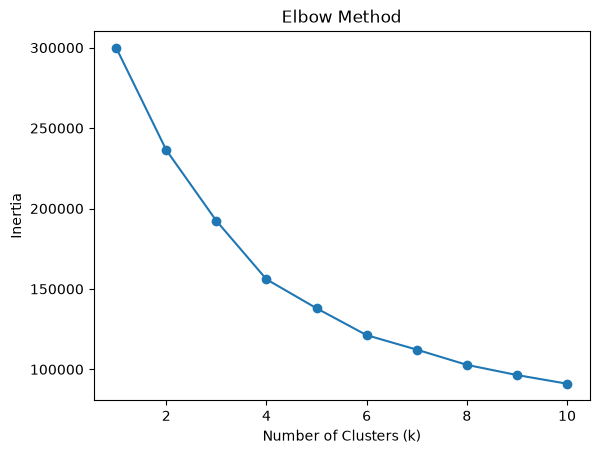

In [8]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

## Step 6: Final KMeans Model & Visualization
Pick `chosen_k` based on the elbow point seen in the graph above, then update
the cell below before running.

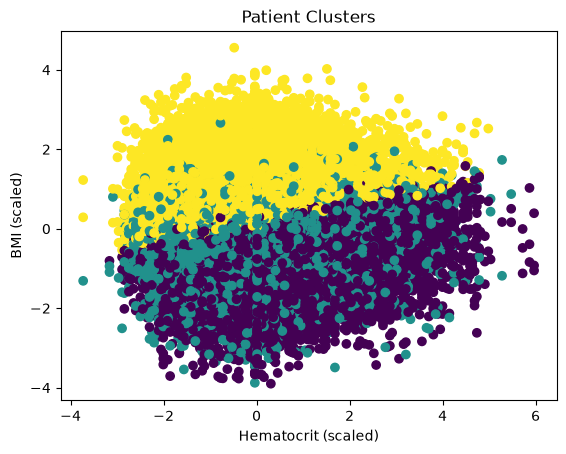

In [9]:
chosen_k = 3  # <-- update this based on your elbow graph

kmeans = KMeans(n_clusters=chosen_k, random_state=42, n_init=10)
kmeans.fit(X_scaled)
labels = kmeans.labels_

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, cmap='viridis')
plt.xlabel("Hematocrit (scaled)")
plt.ylabel("BMI (scaled)")
plt.title("Patient Clusters")
plt.show()

### Clustering Conclusion
Chose k = 3 based on the elbow method — inertia drops sharply from k=1 to k=3, 
then the decrease flattens out significantly, making 3 the point of diminishing returns.

The scatter plot shows clusters separating mainly along the BMI axis: one cluster 
(yellow) groups patients with consistently high BMI regardless of hematocrit level, 
while the other two clusters (teal and purple) represent lower-BMI patients split 
further by hematocrit value. This suggests BMI is the dominant factor distinguishing 
patient groups in this dataset, with hematocrit adding a secondary split — possibly 
reflecting different comorbidity/risk profiles among patients.